In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier
from sklearn.svm import SVC

sns.set_theme()

# Загрузка и преобразование набора данных

In [2]:
df = pd.read_csv("text_embs.csv")
df.head()

,id,article_text,e1,e2,e3,e4,e5
0,0,Spin me round: Conceptual image of the distant...,-22.158750,0.724839,0.288074,-4.338476,-78.955190
1,1,Euclid mission releases its first images\nThe ...,-69.417400,35.862324,-0.087313,-4.319662,71.955670
2,2,"This colourful stripe of stars, gas, and dust ...",-19.161320,16.865223,0.275305,-4.339422,-95.052050
3,3,Scientists say they are stunned after discover...,39.257393,-0.624030,-0.312458,-3.406152,15.344043
4,4,Just a few swabs from a handful of leaves can ...,77.716700,-10.334601,-0.358630,-3.616157,35.430443


In [3]:
known_labels = list(range(6))
df_labeled = df.loc[known_labels]
df_labeled["genre"] = ["cosmos", "cosmos", "cosmos", "biology", "biology", "biology"]
df_labeled

,id,article_text,e1,e2,e3,e4,e5,genre
0,0,Spin me round: Conceptual image of the distant...,-22.158750,0.724839,0.288074,-4.338476,-78.955190,cosmos
1,1,Euclid mission releases its first images\nThe ...,-69.417400,35.862324,-0.087313,-4.319662,71.955670,cosmos
2,2,"This colourful stripe of stars, gas, and dust ...",-19.161320,16.865223,0.275305,-4.339422,-95.052050,cosmos
3,3,Scientists say they are stunned after discover...,39.257393,-0.624030,-0.312458,-3.406152,15.344043,biology
4,4,Just a few swabs from a handful of leaves can ...,77.716700,-10.334601,-0.358630,-3.616157,35.430443,biology
5,5,"Standing on the marina, Rob Skelly peers into ...",25.035158,38.126000,-0.535336,-3.778501,-75.229970,biology


In [4]:
df_unlabeled = df.drop(known_labels)
df_unlabeled.head()

,id,article_text,e1,e2,e3,e4,e5
6,6,The James Webb space telescope has detected wh...,21.771069,-16.705242,0.035637,-4.280477,135.175920
7,7,We all know how important sleep is for mental ...,31.504581,37.482710,0.424354,-3.447748,-138.741090
8,8,"In a former gold mine a mile underground, insi...",-6.323969,-16.945358,-0.056686,-4.229829,112.954500
9,9,Molecular scale structure and kinetics of laye...,34.213360,35.360607,0.041953,-3.384598,-7.783536
10,10,Scientists have discovered new evidence that t...,23.127678,-0.746845,0.399093,-4.260396,-104.567345


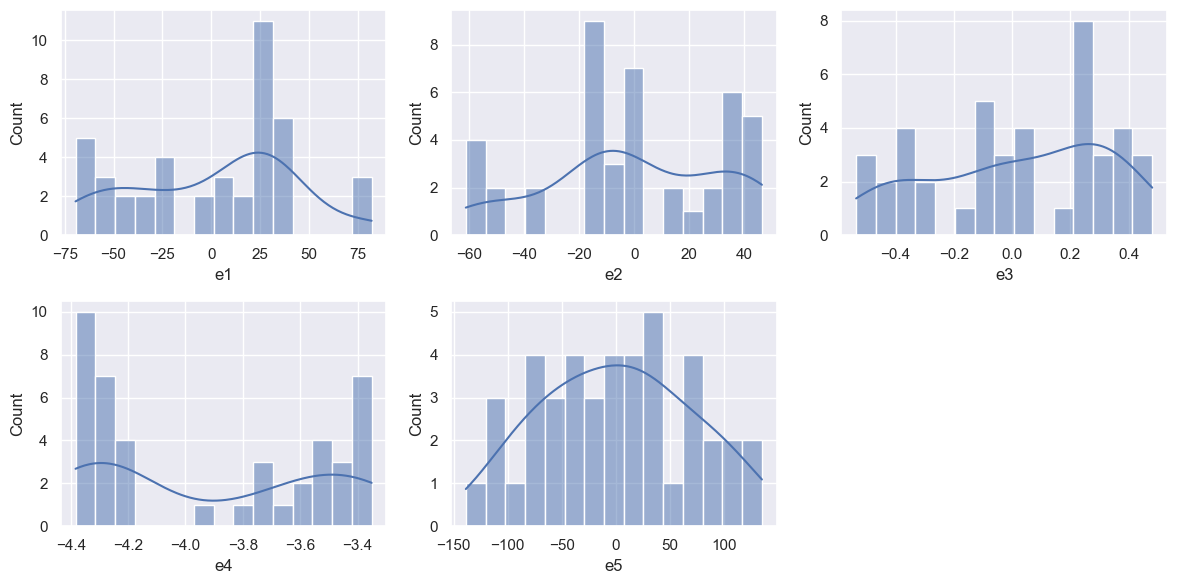

In [5]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
axes = axes.flatten()

for ax, col in zip(axes, df.columns[2:]):
    sns.histplot(data=df, x=col, bins=15, kde=True, ax=ax)

axes[-1].axis("off")

plt.tight_layout();

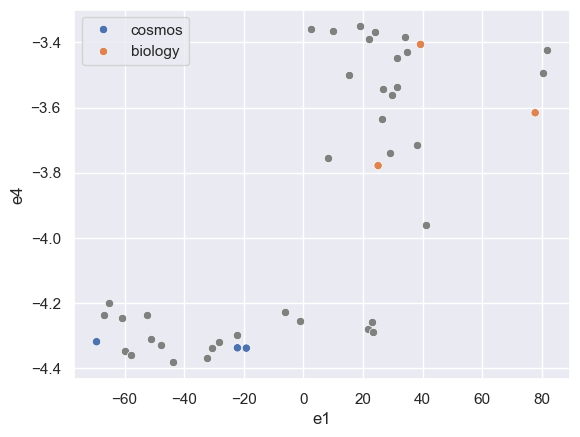

In [6]:
sns.scatterplot(data=df_labeled, x="e1", y="e4", hue="genre")
sns.scatterplot(data=df_unlabeled, x="e1", y="e4", color="grey");

In [7]:
X_unlabeled = df_unlabeled[df.columns[2:]].values
(X_labeled := df_labeled[df.columns[2:]].values)

array([[-2.2158750e+01,  7.2483930e-01,  2.8807366e-01, -4.3384760e+00,
        -7.8955190e+01],
       [-6.9417400e+01,  3.5862324e+01, -8.7312860e-02, -4.3196620e+00,
         7.1955670e+01],
       [-1.9161320e+01,  1.6865223e+01,  2.7530540e-01, -4.3394217e+00,
        -9.5052050e+01],
       [ 3.9257393e+01, -6.2403035e-01, -3.1245756e-01, -3.4061522e+00,
         1.5344043e+01],
       [ 7.7716700e+01, -1.0334601e+01, -3.5863042e-01, -3.6161570e+00,
         3.5430443e+01],
       [ 2.5035158e+01,  3.8126000e+01, -5.3533620e-01, -3.7785013e+00,
        -7.5229970e+01]])

In [8]:
label_encoder = LabelEncoder()
y_labeled = df_labeled.genre.values
(y_encoded := label_encoder.fit_transform(y_labeled))

array([1, 1, 1, 0, 0, 0])

In [9]:
X_all = np.vstack([X_labeled, X_unlabeled])
X_all[:5]

array([[-2.2158750e+01,  7.2483930e-01,  2.8807366e-01, -4.3384760e+00,
        -7.8955190e+01],
       [-6.9417400e+01,  3.5862324e+01, -8.7312860e-02, -4.3196620e+00,
         7.1955670e+01],
       [-1.9161320e+01,  1.6865223e+01,  2.7530540e-01, -4.3394217e+00,
        -9.5052050e+01],
       [ 3.9257393e+01, -6.2403035e-01, -3.1245756e-01, -3.4061522e+00,
         1.5344043e+01],
       [ 7.7716700e+01, -1.0334601e+01, -3.5863042e-01, -3.6161570e+00,
         3.5430443e+01]])

In [10]:
(y_all := np.concatenate([y_encoded, np.full(len(X_unlabeled), -1)]))

array([ 1,  1,  1,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1])

# Частичная разметка при помощи TSVM

In [11]:
self_training = SelfTrainingClassifier(
    estimator=SVC(
        kernel="rbf",
        probability=True,
        random_state=0,
    ),
    threshold=0.75,
    verbose=True,
)

self_training.fit(X_all, y_all)

,estimator,SVC(probabili...andom_state=0)
,base_estimator,'deprecated'
,threshold,0.75
,criterion,'threshold'
,k_best,10
,max_iter,10
,verbose,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [12]:
(y_encoded_tsvm := self_training.predict(X_unlabeled))

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [13]:
(y_unlabeled_tsvm := label_encoder.inverse_transform(y_encoded_tsvm))

array(['cosmos', 'cosmos', 'cosmos', 'biology', 'cosmos', 'cosmos',
       'biology', 'biology', 'cosmos', 'biology', 'biology', 'cosmos',
       'biology', 'biology', 'cosmos', 'biology', 'cosmos', 'biology',
       'cosmos', 'cosmos', 'cosmos', 'cosmos', 'cosmos', 'biology',
       'cosmos', 'biology', 'cosmos', 'biology', 'cosmos', 'biology',
       'cosmos', 'biology', 'cosmos', 'cosmos', 'biology', 'biology',
       'cosmos'], dtype=object)

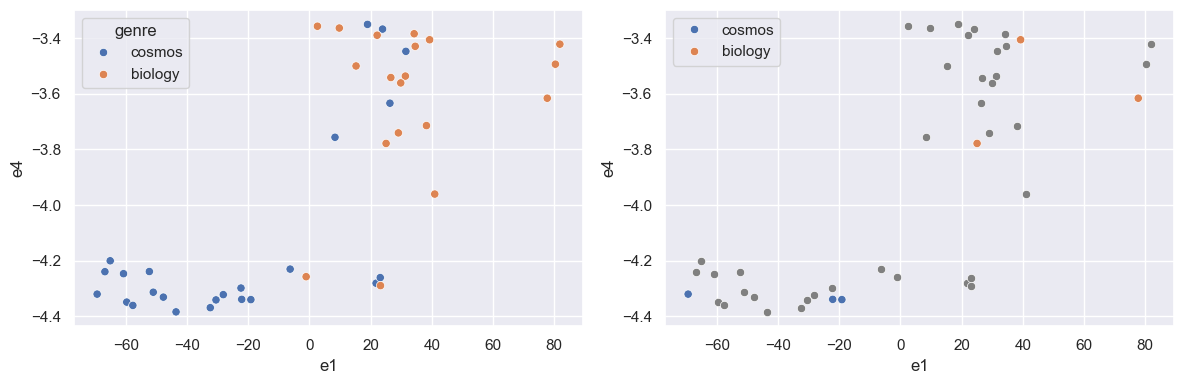

In [14]:
df_unlabeled_tsvm = df_unlabeled.copy()
df_unlabeled_tsvm["genre"] = y_unlabeled_tsvm

df_tsvm = pd.concat([df_labeled, df_unlabeled_tsvm])

_, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.scatterplot(data=df_tsvm, x="e1", y="e4", hue="genre", ax=axes[0])

sns.scatterplot(data=df_labeled, x="e1", y="e4", hue="genre", ax=axes[1])
sns.scatterplot(data=df_unlabeled, x="e1", y="e4", color="grey", ax=axes[1])

plt.tight_layout();

# Частичная разметка графовым методом

In [15]:
graph_model = LabelSpreading(
    kernel="knn",
    n_neighbors=7,
    alpha=0.2,
)

graph_model.fit(X_all, y_all)

(y_encoded_knn_graph := graph_model.transduction_)

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1])

In [16]:
(y_all_knn_graph := label_encoder.inverse_transform(y_encoded_knn_graph))

array(['cosmos', 'cosmos', 'cosmos', 'biology', 'biology', 'biology',
       'biology', 'cosmos', 'biology', 'biology', 'cosmos', 'cosmos',
       'biology', 'biology', 'cosmos', 'biology', 'biology', 'cosmos',
       'biology', 'biology', 'cosmos', 'biology', 'cosmos', 'biology',
       'cosmos', 'cosmos', 'biology', 'cosmos', 'cosmos', 'biology',
       'cosmos', 'biology', 'cosmos', 'biology', 'cosmos', 'biology',
       'cosmos', 'biology', 'biology', 'cosmos', 'biology', 'biology',
       'cosmos'], dtype=object)

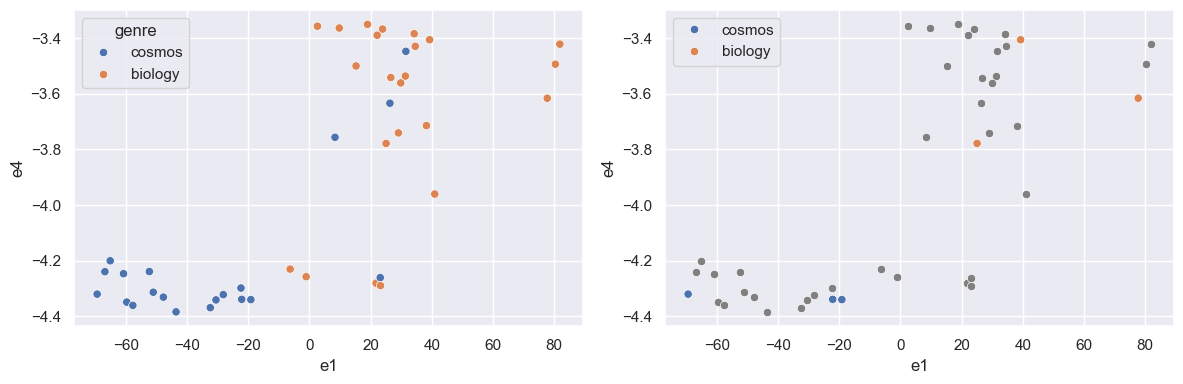

In [17]:
df_knn_model = pd.concat([df_labeled, df_unlabeled])
df_knn_model["genre"] = y_all_knn_graph

_, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.scatterplot(data=df_knn_model, x="e1", y="e4", hue="genre", ax=axes[0])

sns.scatterplot(data=df_labeled, x="e1", y="e4", hue="genre", ax=axes[1])
sns.scatterplot(data=df_unlabeled, x="e1", y="e4", color="grey", ax=axes[1])

plt.tight_layout();

In [18]:
df_knn_model.to_csv("text_embs_labeled.csv", index=False)